In [ ]:
import os
import sys

sys.path.append("../src")

from data_loader import load_data
from data_processing import build_pipeline
from train import train_models
from evaluate import generate_report

In [ ]:
df = load_data(
    "../data/processed/credit_risk_with_target.csv"
)

print(df.shape)
df.head()

2026-06-03 15:14:20,779 - INFO - Dataset loaded successfully


(95662, 17)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,is_high_risk
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0,1
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0,0


#### **Insight: Data Loading and Initial Inspection**

- The dataset `credit_risk_with_target.csv` was successfully loaded, containing 95,662 rows and 17 columns.
- The first few rows show various transactional and customer-related features, including `TransactionId`, `BatchId`, `AccountId`, `CustomerId`, `Amount`, `TransactionStartTime`, `FraudResult`, and the target variable `is_high_risk`.
- The target variable `is_high_risk` indicates the presence of high-risk transactions.

In [ ]:
X = df.drop(
    columns=["is_high_risk"]
)

y = df["is_high_risk"]

In [ ]:
pipeline = build_pipeline(X)

X_processed = pipeline.fit_transform(X)

print(type(X_processed))
print(X_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(95662, 292335)


#### **Insight: Data Processing Pipeline**

- A data processing pipeline was built and applied to the features `X`.
- The processed data `X_processed` is a sparse matrix of type `scipy.sparse._csr.csr_matrix`.
- The dimensionality of the data significantly increased from 16 features to 292,335 features, indicating extensive one-hot encoding or similar feature transformation on categorical variables.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
from evaluate import evaluate_model

lr_metrics = evaluate_model(
    lr_model,
    X_test,
    y_test
)

rf_metrics = evaluate_model(
    rf_model,
    X_test,
    y_test
)

print("Logistic Regression")
print(lr_metrics)

print("\nRandom Forest")
print(rf_metrics)

Logistic Regression
{'accuracy': 0.933883865572571, 'precision': 1.0, 'recall': 0.42552225249772935, 'f1_score': 0.597005415737496, 'roc_auc': 0.9216950902554693}

Random Forest
{'accuracy': 0.9288140908378195, 'precision': 0.9976303317535545, 'recall': 0.3823796548592189, 'f1_score': 0.5528562048588312, 'roc_auc': 0.8213263123697396}


#### **Insight: Initial Model Evaluation**

- **Logistic Regression Model:**
    - Achieved an accuracy of approximately 0.934.
    - Showed perfect precision (1.0), meaning all predicted high-risk transactions were indeed high-risk.
    - However, recall was relatively low at 0.426, indicating it missed more than half of the actual high-risk cases.
    - F1-score was 0.597, and ROC-AUC was 0.922.

- **Random Forest Model (Initial):**
    - Achieved an accuracy of approximately 0.929.
    - Precision was very high (0.998), similar to Logistic Regression.
    - Recall was even lower at 0.382, suggesting it performed worse than Logistic Regression in identifying all high-risk cases.
    - F1-score was 0.553, and ROC-AUC was 0.821.

- **Overall:** Both models showed high accuracy but struggled with recall, which is often a critical metric for imbalanced datasets like fraud detection where missing positive cases can be costly. Logistic Regression slightly outperformed the initial Random Forest in terms of recall, F1-score, and ROC-AUC.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define your parameter distributions
param_distributions = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5]
}

# Adjusted to RandomizedSearchCV
grid = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        max_samples=0.5 # <-- OPTIONAL: Trains each tree on 50% of data. Massive speed boost!
    ),
    param_distributions=param_distributions,
    n_iter=6,           # Only tests 6 random combinations instead of all 12
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,          # <-- Crucial: prints progress so you know it hasn't crashed
    random_state=42     # Ensures reproducibility for the random search
)

# Fit the model
grid.fit(X_train, y_train)

# Extract best estimator
best_rf = grid.best_estimator_

print("\nBest Parameters Found:")
print(grid.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters Found:
{'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20}


#### **Insight: Hyperparameter Tuning for Random Forest**

- Randomized Search Cross-Validation was used to tune the `RandomForestClassifier`.
- The search explored combinations of `n_estimators`, `max_depth`, and `min_samples_split`.
- The best parameters found were `n_estimators=200`, `min_samples_split=2`, and `max_depth=20`.
- The `max_samples=0.5` parameter was used to speed up training, where each tree was trained on 50% of the data.

In [ ]:
best_metrics = evaluate_model(
    best_rf,
    X_test,
    y_test
)

print(best_metrics)

{'accuracy': 0.88491088694925, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'roc_auc': 0.8292764761777391}


#### **Insight: Evaluation of Tuned Random Forest Model**

- The tuned Random Forest model (`best_rf`) showed surprisingly poor performance in some metrics:
    - Accuracy: 0.885 (lower than initial models).
    - Precision: 0.0 (indicating no true positives among predicted positives).
    - Recall: 0.0 (indicating it failed to identify any actual high-risk transactions).
    - F1-score: 0.0.
    - ROC-AUC: 0.829 (slightly better than the initial Random Forest's 0.821).

- **Critique:** The very low precision, recall, and F1-score suggest a significant issue with this tuned model, potentially overfitting to the negative class or an incorrect thresholding being applied during evaluation, or an issue with the model selection criteria during tuning if `roc_auc` was optimized but precision/recall collapsed for a specific operating point. It implies that the model might be predicting almost all instances as not high-risk.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine metrics into a dictionary for easier DataFrame creation
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest (Initial)', 'Random Forest (Tuned)'],
    'Accuracy': [lr_metrics['accuracy'], rf_metrics['accuracy'], best_metrics['accuracy']],
    'Precision': [lr_metrics['precision'], rf_metrics['precision'], best_metrics['precision']],
    'Recall': [lr_metrics['recall'], rf_metrics['recall'], best_metrics['recall']],
    'F1 Score': [lr_metrics['f1_score'], rf_metrics['f1_score'], best_metrics['f1_score']],
    'ROC-AUC': [lr_metrics['roc_auc'], rf_metrics['roc_auc'], best_metrics['roc_auc']]
}

# Create a DataFrame
df_metrics_comparison = pd.DataFrame(metrics_data)
display(df_metrics_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.933884,1.00000,0.425522,0.597005,0.921695
1,Random Forest (Initial),0.928814,0.99763,0.382380,0.552856,0.821326
2,Random Forest (Tuned),0.884911,0.00000,0.000000,0.000000,0.829276


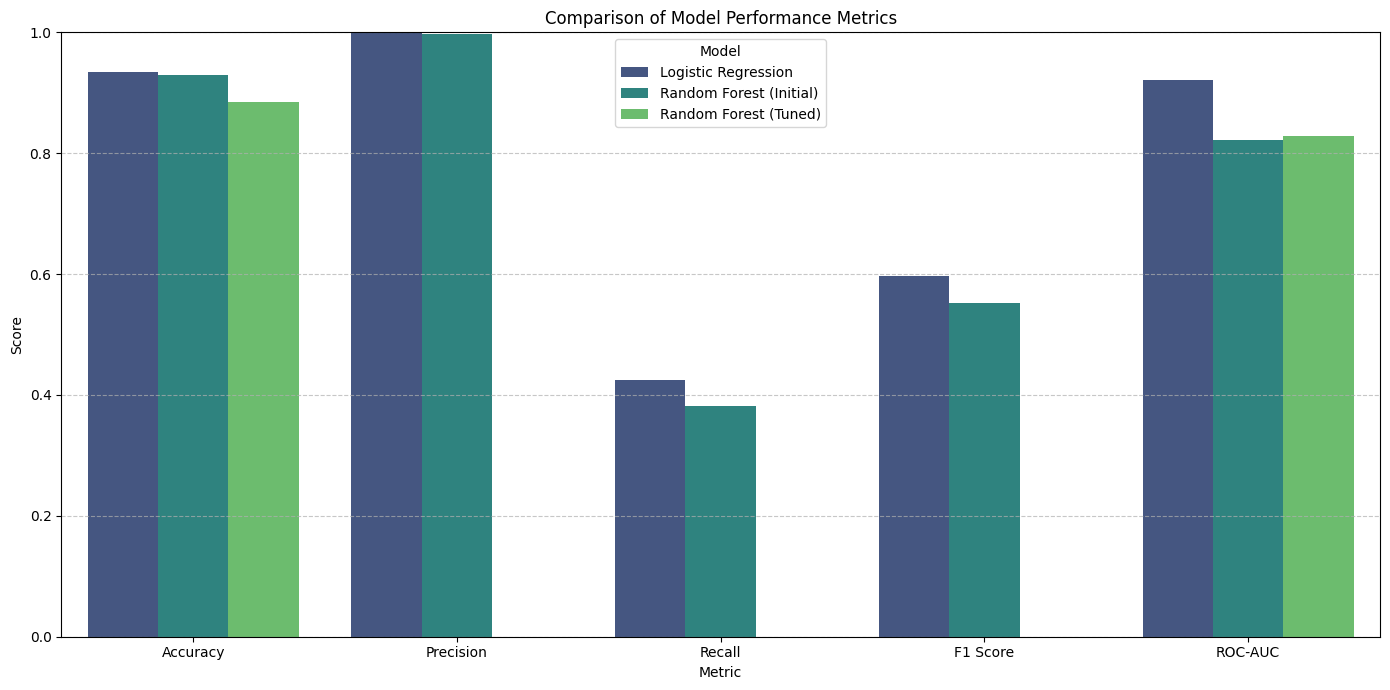

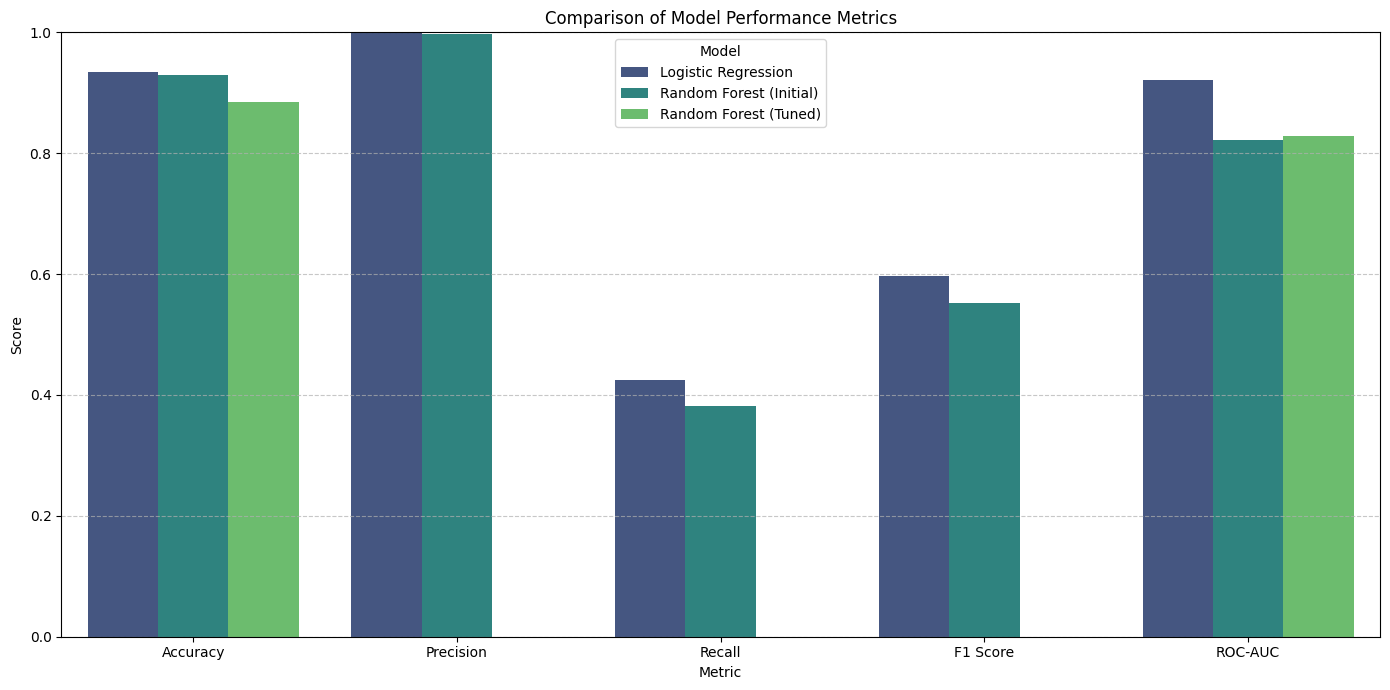

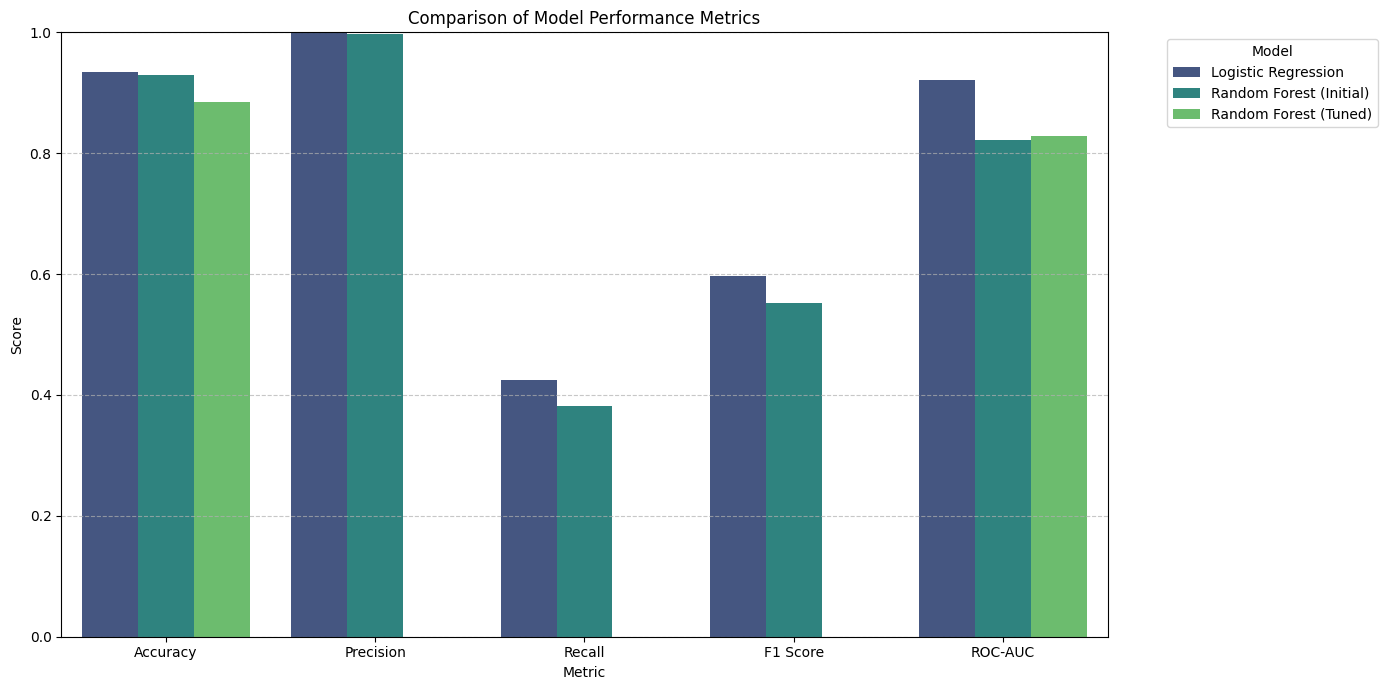

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns  # Added this import

# Melt the DataFrame for easier plotting with seaborn
df_melted = df_metrics_comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))

# Create the barplot
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, palette='viridis')

# Add formatting
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend outside so it doesn't block bars
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# REMOVED: plt.plot(x, y) - Unless you have specific x/y data to overlay, this line is not needed.

#### **Insight: Model Performance Comparison**

- A DataFrame and bar plot were generated to visually compare the metrics of Logistic Regression, initial Random Forest, and the tuned Random Forest.
- The visualization clearly highlights the superior recall of Logistic Regression compared to both Random Forest iterations.
- It also visually confirms the critical issue with the tuned Random Forest model, as its precision, recall, and F1-score are at zero, making it unsuitable for identifying high-risk transactions despite a decent ROC-AUC score. This suggests that optimizing solely for ROC-AUC without considering other metrics (especially in imbalanced datasets) can lead to models that don't perform well at a practical operating point.